# Smoke test: CIGALE mixed discrete/continuous prior

This notebook is a fast wiring test for CIGALE through `sedinfer` using a mixed random-variable prior.

It checks three sampler modes:

1. `run_grid_sampler`: the plain CIGALE-style Cartesian grid evaluator, using a fully discrete copy of the prior.
2. `run_mixed_gibbs`: a two-block sampler, continuous block first and thresholded SIR over the discrete grid second.
3. `run_mixed_tamis`: a joint mixed adaptive importance sampler with a Gaussian-mixture continuous proposal and categorical discrete proposal.

The mock photometry is generated by the same `CIGALEBackend` used in the fit. This is a smoke test, so the module chain and sampler settings are intentionally tiny.


## Scientific data flow

1. We define one small CIGALE module chain: `sfhdelayed -> bc03 -> redshifting`.
2. The backend enforces `normalise=True` for the SFH module, so CIGALE returns photometry per solar mass.
3. `GaussianPhotometricLikelihood` applies `10**log10_mass` exactly once because the backend declares `PER_SOLAR_MASS`.
4. Mock fluxes are generated in maggies in native CIGALE filters.
5. Gaussian noise is added in maggies.
6. The fit uses continuous random variables (`log10_mass`, `tau_main`, `z`) and discrete random variables (`age_main`, `metallicity`).
7. The plotted summaries compare posterior samples to the known truth.

Main audit points:

- the module and prior declarations;
- the single mass-normalization point in the likelihood;
- the discrete values listed for `age_main` and `metallicity`;
- the sampler calls at the end.


In [1]:
from __future__ import annotations

import importlib.util
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/Users/gregoire/Documents/Sedfitting/sedinfer-public')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# If you work from a source checkout of CIGALE rather than an installed package,
# add it here. This mirrors the other validation notebooks.
CIGALE_SOURCE = Path('/Users/gregoire/Work/cigale-v2022.0')
if CIGALE_SOURCE.exists() and str(CIGALE_SOURCE) not in sys.path:
    sys.path.insert(0, str(CIGALE_SOURCE))

OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / 'cigale_mixed_prior_smoke'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NOTEBOOK = importlib.util.find_spec('pcigale') is not None
print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('pcigale importable:', RUN_NOTEBOOK)


Repository: /Users/gregoire/Documents/Sedfitting/sedinfer-public
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/cigale_mixed_prior_smoke
pcigale importable: True


In [2]:
if not RUN_NOTEBOOK:
    raise ImportError(
        'pcigale is not importable in this Python environment. '
        'Open this notebook in the CIGALE environment or add the CIGALE source path above.'
    )

from inftools import run_grid_sampler, run_mixed_gibbs, run_mixed_tamis
from inftools.mcmc import run_rw_metropolis
from sedinfer import GaussianPhotometricLikelihood, SEDDataset
from sedinfer.backends.cigale import build_cigale_backend_and_parameter_space
from sedinfer.filters import FilterSet
from sedinfer.priors import ChoicePrior, UniformPrior


In [3]:
MODULES = ['sfhdelayed', 'bc03', 'redshifting']

MODULE_PARAMETERS_MIXED = {
    'sfhdelayed': {
        'tau_main': {'range': [500.0, 5000.0]},        # Myr, continuous
        'age_main': {'values': [1000, 3000, 5000], 'dtype': 'int'},
    },
    'bc03': {
        'imf': 1,
        'metallicity': {'values': [0.008, 0.02]},
    },
    'redshifting': {
        'redshift': {'name': 'z', 'range': [0.05, 1.0]},
    },
}

FILTER_NAMES = ['sdss.up', 'sdss.gp', 'sdss.rp']
filters = FilterSet(FILTER_NAMES)

truth = {
    'log10_mass': 10.2,
    'tau_main': 1800.0,
    'age_main': 3000.0,
    'metallicity': 0.02,
    'z': 0.35,
}

backend, parameter_space = build_cigale_backend_and_parameter_space(
    MODULES,
    MODULE_PARAMETERS_MIXED,
    additional_priors={'log10_mass': UniformPrior(8.5, 11.5)},
    photometry_mode='cigale',
)

print('Parameter order:', parameter_space.names)
print('Mass normalization:', backend.mass_normalization.name)
print('Filters:', FILTER_NAMES)


Parameter order: ('log10_mass', 'tau_main', 'age_main', 'metallicity', 'z')
Mass normalization: PER_SOLAR_MASS
Filters: ['sdss.up', 'sdss.gp', 'sdss.rp']


In [4]:
rng = np.random.default_rng(12)

theta_true = parameter_space.from_dict(truth)
placeholder = SEDDataset(
    band_names=FILTER_NAMES,
    flux=np.ones(len(FILTER_NAMES)),
    sigma=np.ones(len(FILTER_NAMES)),
    metadata={'filters': filters},
)
truth_like = GaussianPhotometricLikelihood(backend, placeholder, parameter_space, filters=filters)
noiseless_flux = truth_like.simulate(theta_true, noise_fn=lambda flux: np.zeros_like(flux), rng=rng)

relative_error = 0.08
noise_floor = 1e-13
sigma = relative_error * np.abs(noiseless_flux) + noise_floor
observed_flux = noiseless_flux + rng.normal(0.0, sigma)

mock_data = SEDDataset(
    band_names=FILTER_NAMES,
    flux=observed_flux,
    sigma=sigma,
    metadata={'filters': filters, 'truth': truth},
)
likelihood = GaussianPhotometricLikelihood(backend, mock_data, parameter_space, filters=filters)

phot_table = pd.DataFrame({
    'band': FILTER_NAMES,
    'noiseless_maggies': noiseless_flux,
    'observed_maggies': observed_flux,
    'sigma_maggies': sigma,
    'SNR': observed_flux / sigma,
})

display(phot_table)
print('Truth log posterior:', likelihood.log_prob(theta_true))
assert np.all(np.isfinite(observed_flux))
assert np.all(sigma > 0)


/Users/gregoire/Work/cigale-v2022.0/pcigale/data/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,band,noiseless_maggies,observed_maggies,sigma_maggies,SNR
0,sdss.up,6.160548e-09,6.517418e-09,4.929438e-10,13.221421
1,sdss.gp,7.323450e-09,8.272014e-09,5.859760e-10,14.116643
2,sdss.rp,1.344691e-08,1.214991e-08,1.075853e-09,11.293280


Truth log posterior: 47.03183357972462


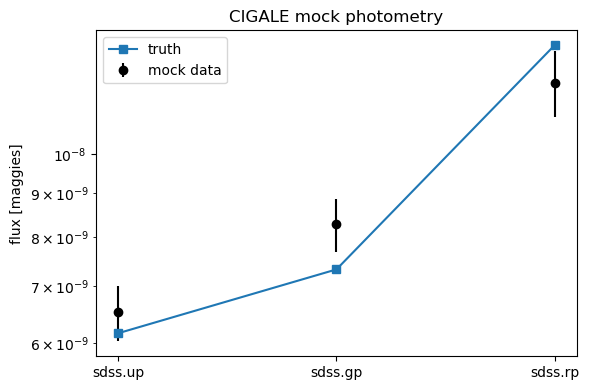

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(FILTER_NAMES))
ax.errorbar(x, observed_flux, yerr=sigma, fmt='o', color='black', label='mock data')
ax.plot(x, noiseless_flux, 's-', color='tab:blue', label='truth')
ax.set_xticks(x, FILTER_NAMES)
ax.set_ylabel('flux [maggies]')
ax.set_yscale('log')
ax.legend()
ax.set_title('CIGALE mock photometry')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mock_photometry.png', dpi=160)
plt.show()


## Plain CIGALE-style grid run

`run_grid_sampler` only accepts finite-valued parameters. To exercise that official CIGALE mode in this smoke test, we make a coarse all-discrete copy of the prior. This is not the mixed-RV fit; it is the all-grid baseline.


In [6]:
MODULE_PARAMETERS_GRID = {
    'sfhdelayed': {
        'tau_main': {'values': [1000.0, 1800.0, 3500.0]},
        'age_main': {'values': [1000, 3000, 5000], 'dtype': 'int'},
    },
    'bc03': {
        'imf': 1,
        'metallicity': {'values': [0.008, 0.02]},
    },
    'redshifting': {
        'redshift': {'name': 'z', 'values': [0.25, 0.35, 0.50]},
    },
}

grid_backend, grid_space = build_cigale_backend_and_parameter_space(
    MODULES,
    MODULE_PARAMETERS_GRID,
    additional_priors={'log10_mass': ChoicePrior([9.8, 10.2, 10.6])},
    photometry_mode='cigale',
)
grid_like = GaussianPhotometricLikelihood(grid_backend, mock_data, grid_space, filters=filters)

grid_result = run_grid_sampler(
    posterior=type('PosteriorLike', (), {
        'log_prob_fn': grid_like.log_prob,
        'dim': grid_space.ndim,
        'theta_names': grid_space.names,
    })(),
    parameter_space=grid_space,
)

grid_df = pd.DataFrame(grid_result.samples, columns=grid_space.names)
grid_df['logp'] = grid_result.logp
grid_df['weight'] = grid_result.meta['weights_norm']
display(grid_df.sort_values('weight', ascending=False).head(8))
print('Grid MAP:', dict(zip(grid_space.names, grid_result.map_estimate)))


,log10_mass,tau_main,age_main,metallicity,z,logp,weight
82,10.2,1800.0,3000.0,0.020,0.35,53.195148,0.351429
24,9.8,1800.0,3000.0,0.008,0.25,52.900652,0.261782
45,9.8,3500.0,3000.0,0.020,0.25,52.816371,0.240623
137,10.6,1800.0,3000.0,0.020,0.50,52.037327,0.110409
79,10.2,1800.0,3000.0,0.008,0.35,50.604644,0.026351
27,9.8,1800.0,3000.0,0.020,0.25,49.309419,0.007216
87,10.2,1800.0,5000.0,0.020,0.25,47.514853,0.001199
142,10.6,1800.0,5000.0,0.020,0.35,47.219830,0.000893


Grid MAP: {'log10_mass': 10.2, 'tau_main': 1800.0, 'age_main': 3000.0, 'metallicity': 0.02, 'z': 0.35}


## Mixed prior fits

Now we return to the actual mixed prior: continuous `log10_mass`, `tau_main`, and `z`; discrete `age_main` and `metallicity`.


In [7]:
from inftools.core import Posterior

posterior = Posterior(likelihood.log_prob, dim=parameter_space.ndim, theta_names=parameter_space.names)

x0 = parameter_space.from_dict({
    'log10_mass': 10.0,
    'tau_main': 2500.0,
    'age_main': 3000.0,
    'metallicity': 0.02,
    'z': 0.4,
})

gibbs_result = run_mixed_gibbs(
    posterior,
    parameter_space,
    x0=x0,
    nsteps=12,
    continuous_sampler=run_rw_metropolis,
    continuous_sampler_kwargs={
        'nsteps': 25,
        'burnin': 10,
        'thin': 1,
        'proposal_cov': np.diag([0.02**2, 200.0**2, 0.04**2]),
    },
    discrete_candidates=None,
    discrete_probability_floor='survival',
    rng=np.random.default_rng(13),
)

mixed_tamis_result = run_mixed_tamis(
    posterior,
    parameter_space,
    x0=x0,
    n_comp=2,
    T_max=3,
    n_per_iter=60,
    init_span=0.5,
    var0=np.array([0.1**2, 600.0**2, 0.12**2]),
    alpha=25,
    seed=14,
)

print('Gibbs MAP:', dict(zip(parameter_space.names, gibbs_result.map_estimate)))
print('Mixed TAMIS MAP:', dict(zip(parameter_space.names, mixed_tamis_result.map_estimate)))
print('Mixed TAMIS betas:', mixed_tamis_result.meta['betas'])


Gibbs MAP: {'log10_mass': 9.894130329870688, 'tau_main': 3305.1944464879234, 'age_main': 3000.0, 'metallicity': 0.02, 'z': 0.2870308497051912}
Mixed TAMIS MAP: {'log10_mass': 10.283844607634729, 'tau_main': 2372.9119677984568, 'age_main': 3000.0, 'metallicity': 0.02, 'z': 0.396953638034058}
Mixed TAMIS betas: [0.01914362 0.03042922 0.04192092]


In [8]:
def weighted_quantile(values, weights, qs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order] / np.sum(weights)
    cdf = np.cumsum(weights)
    return np.interp(qs, cdf, values)

summary_rows = []
for name, result, weights in [
    ('gibbs', gibbs_result, np.ones(len(gibbs_result.samples)) / len(gibbs_result.samples)),
    ('mixed_tamis', mixed_tamis_result, mixed_tamis_result.meta['weights_norm']),
]:
    for j, pname in enumerate(parameter_space.names):
        q16, q50, q84 = weighted_quantile(result.samples[:, j], weights, [0.16, 0.50, 0.84])
        summary_rows.append({
            'sampler': name,
            'parameter': pname,
            'truth': truth[pname],
            'q16': q16,
            'median': q50,
            'q84': q84,
        })
summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(OUTPUT_DIR / 'mixed_prior_smoke_summary.csv', index=False)


,sampler,parameter,truth,q16,median,q84
0,gibbs,log10_mass,10.20,9.891603,9.946285,9.972734
1,gibbs,tau_main,1800.00,2238.113686,2999.120842,3402.213669
2,gibbs,age_main,3000.00,3000.000000,3000.000000,3000.000000
3,gibbs,metallicity,0.02,0.008000,0.020000,0.020000
4,gibbs,z,0.35,0.276600,0.288489,0.315403
5,mixed_tamis,log10_mass,10.20,10.281083,10.347775,10.436800
6,mixed_tamis,tau_main,1800.00,2265.059975,2686.012090,2888.780673
7,mixed_tamis,age_main,3000.00,3000.000000,3000.000000,5000.000000
8,mixed_tamis,metallicity,0.02,0.008000,0.020000,0.020000
9,mixed_tamis,z,0.35,0.361564,0.421091,0.484901


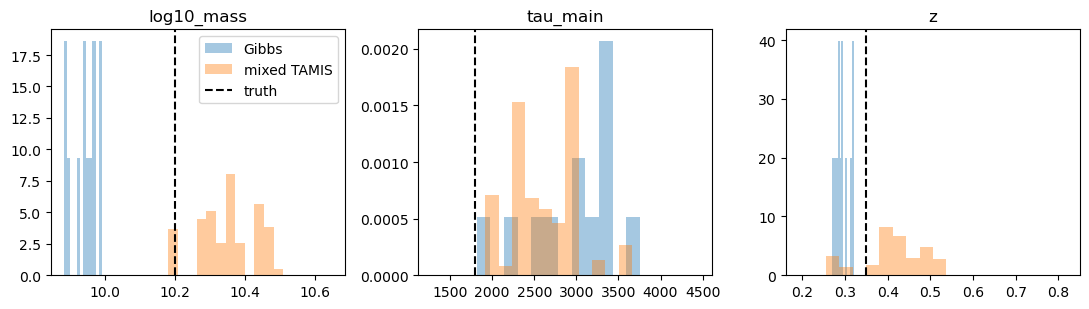

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
plot_params = ['log10_mass', 'tau_main', 'z']
for ax, pname in zip(axes, plot_params):
    j = parameter_space.names.index(pname)
    ax.hist(gibbs_result.samples[:, j], bins=12, alpha=0.4, density=True, label='Gibbs')
    ax.hist(mixed_tamis_result.samples[:, j], bins=20, alpha=0.4, density=True, weights=mixed_tamis_result.meta['weights_norm'], label='mixed TAMIS')
    ax.axvline(truth[pname], color='black', linestyle='--', label='truth' if pname == plot_params[0] else None)
    ax.set_title(pname)
axes[0].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mixed_prior_smoke_posteriors.png', dpi=160)
plt.show()
